In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

def data_path(filename):
    return DATA_DIR / filename

In [1]:
df = pd.read_excel(data_path("Online Retail.xlsx"))
df.head(2)

NameError: name 'pd' is not defined

# Data Profiling

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


## Controllo valori mancanti

In [5]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.loc[(df["Description"].isna()) & (df["CustomerID"].isna())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


## Controllo se ci sono righe duplicate

In [7]:
df.duplicated().sum()

np.int64(5268)

## Controllo se ci sono outlier

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df.sort_values("Quantity", ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,2011-06-09 15:04:00,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom


In [10]:
df.sort_values("UnitPrice", ascending=False).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


## Controllo valori negativi

In [11]:
df.loc[(df["Quantity"] < 0) & (df["InvoiceNo"].str.startswith("C"))]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [12]:
df.loc[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


# DATA CLEANING
Dopo aver creato una copia del df, inizio a fare data cleaning su df_clean dove:

* elimino le righe duplicate
* sostituisco i valori mancanti in _Description_ con _Missing_ e mantengo inalterati quelli di _CustomerID_
* escludo i valori con _Quantity_ e _UnitPrice_ negativi, per escludere resi o note di credite che possono falsare le analisi di spesa del cliente
* mantengo gli outlier, in quanto significativi in sede di EDA

## Creo una copia del df

In [13]:
df_clean = df.copy()

## Elimino le righe duplicate

In [14]:
df_clean.drop_duplicates(inplace=True)

## Gestisco i valori mancanti

In [15]:
df_clean["Description"] = df_clean["Description"].fillna("MISSING")

## Escludo i valori negativi

In [16]:
df_clean = df_clean[(df_clean["Quantity"] >= 0) & (df_clean["UnitPrice"] >= 0)]

# FEATURE ENGINEERING
Creo le colonne: 

* _Continent_ per condurre indagini sulla distribuzione geografica delle vendite
* _TotalPrice_ per poter analizzare l'importo di ogni fattura
* _Year_, _Month_, _Day_ e _DayName_ per valutare l'andamento delle vendite nel tempo. 

La colonna _Quantity_ non presenta valori pari a zero, mentre la _UnitPrice_ ne ha 1174, di cui 592 corrispondono ad una _Description_ mancante. Probabilmente, quelli che non hanno _Description_ mancante corrispondono a promozioni o sconti erogati a clienti mentre per i restanti può trattarsi di un errore di registrazione.

## Creo la colonna Continent

In [17]:
continent_segment_map = {
    "Africa": ["RSA"],
    "America": ["Brazil", "Canada", "USA"],
    "Asia": ["Bahrain", "Hong Kong", "Israel", "Japan", "Lebanon", "Saudi Arabia", "Singapore", "United Arab Emirates"],
    "Europe": ["Austria", "Belgium", "Channel Islands", "Cyprus", "Czech Republic", "Denmark", "EIRE", "European Community",
               "Finland", "France", "Germany", "Greece", "Iceland", "Italy", "Lithuania", "Malta", "Netherlands", "Norway", 
               "Poland", "Portugal", "Spain", "Sweden", "Switzerland", "United Kingdom"],
    "Oceania": ["Australia"],
    "Other": ["Unspecified"]
}

In [121]:
def map_continent_segment(country):
    for segment, country_list in continent_segment_map.items():
        if country in country_list:
            return segment
    return "Other"

In [19]:
df_clean["Continent"] = df_clean["Country"].apply(map_continent_segment)

## Creo la colonna TotalPrice

In [20]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

## Estraggo le colonne Year, Month, Day and DayName

In [21]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["DayName"] = df_clean["InvoiceDate"].dt.day_name()

## Controllo valori di Quantity e UnitPrice pari a 0

In [22]:
df_clean[df_clean["Quantity"] == 0].shape[0]

0

In [23]:
df_clean[df_clean["UnitPrice"] == 0].shape[0]

1174

In [81]:
df_clean[(df_clean["UnitPrice"] == 0) & (df_clean["Description"] == "MISSING")].shape[0]

592

# EDA

## Business Overview
Dall'analisi preliminare del dataset, questi sono i numeri più importanti:

* 10'642'110 sterline di fatturato prodotto
* 4339 clienti serviti
* 20'726 fatture emesse
* 3941 prodotti venduti

### Fatturato totale

In [145]:
total_revenue = df_clean["TotalPrice"].sum()
total_revenue

np.float64(10642110.804000001)

### Numero clienti

In [146]:
total_customers = df_clean["CustomerID"].nunique()
total_customers

4339

### Numero fatture

In [147]:
total_invoices = df_clean["InvoiceNo"].nunique()
total_invoices

20726

### Numero prodotti

In [148]:
total_products = df_clean["StockCode"].nunique()
total_products

3941

## Transaction Analysis
La distribuzione del fatturato per transazione eseguita risulta fortemente asimmetrica a destra, con la maggior parte delle fatture con importi contenuti. Si evidenzia la presenza di un ristretto numero di fatture che presentano importi superiori a 150 mila sterline per transazione.

Anche il confronto tra fatture emesse e quantità ordinate mostra una distribuzione fortemente right-skewed, in quanto il 75% delle transazioni presenta pochi prodotti fatturati. C'è un ristretto numero di outlier che registrano ordini tra le 75 mila e le 80 mila unità di prodotti per fattura.

Analizzando le quantità di articoli ordinati e i prezzi applicati ad ognuno, viene fuori una distribuzione asimmetricamente positiva, con la maggior parte delle vendite caratterizzate da volumi e prezzi contenuti.

### Fatturato per transazione

In [29]:
invoice_revenue = df_clean.groupby("InvoiceNo")["TotalPrice"].sum()
invoice_revenue.describe()

count     20726.000000
mean        513.466699
std        1750.093548
min           0.000000
25%         137.787500
50%         297.340000
75%         480.355000
max      168469.600000
Name: TotalPrice, dtype: float64

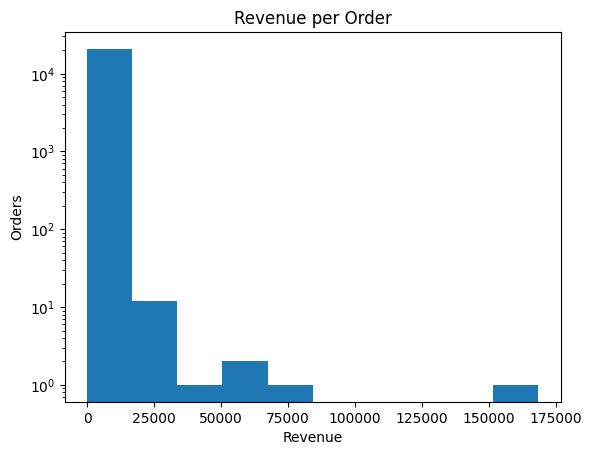

In [128]:
plt.hist(invoice_revenue, log=True)
plt.title("Revenue per Order")
plt.xlabel("Revenue")
plt.ylabel("Orders")
plt.show()

### Average Basket Size

In [31]:
invoice_quantity = df_clean.groupby("InvoiceNo")["Quantity"].sum()
invoice_quantity.describe()

count    20726.000000
mean       272.364036
std        944.059110
min          1.000000
25%         63.000000
50%        145.000000
75%        288.000000
max      80995.000000
Name: Quantity, dtype: float64

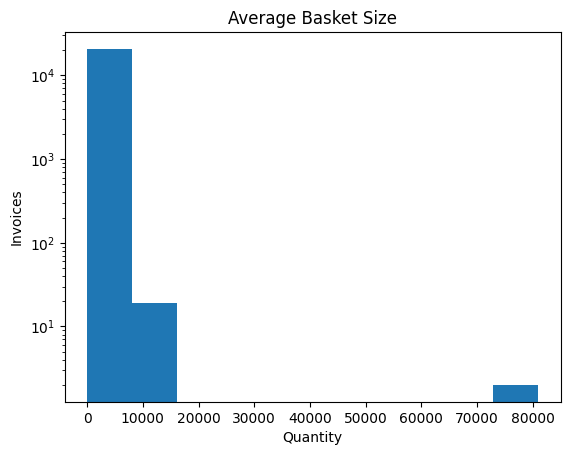

In [32]:
plt.hist(invoice_quantity, log=True)
plt.title("Average Basket Size")
plt.xlabel("Quantity")
plt.ylabel("Invoices")
plt.show()

### Distribuzione di Quantity e UnitPrice

In [93]:
df_clean[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,526052.000000,526052.000000
mean,10.730911,3.913818
std,157.592136,36.053205
min,1.000000,0.000000
25%,1.000000,1.250000
50%,4.000000,2.080000
75%,11.000000,4.130000
max,80995.000000,13541.330000


## Time Analysis
Dall’analisi del fatturato del 2011 emerge una crescita progressiva delle vendite verso i mesi finali dell’anno, con un picco massimo a novembre, seguito da una flessione nel mese di dicembre.
Non è possibile effettuare un confronto significativo con il 2010, poiché il dataset contiene dati inerenti al solo mese di dicembre.

Il grafico delle vendite giornalieri mostra una distribuzione regolare nei giorni lavorativi, con attività anche di domenica, seppure con volumi più contenuti. Il sabato, invece, non si registrano vendite.

### Vendite per anno e mese

In [149]:
total_price = df_clean.groupby(["Year", "Month"]).agg(TotalPrice=("TotalPrice", "sum"))
total_price

TotalPrice
Year Month             
2010 12      821452.730
2011 1       689811.610
     2       522545.560
     3       716215.260
     4       536968.491
     5       769296.610
     6       760547.010
     7       718076.121
     8       757841.380
     9      1056435.192
     10     1151263.730
     11     1503866.780
     12      637790.330

In [35]:
total_price_2010 = total_price.loc[2010]
total_price_2011 = total_price.loc[2011]

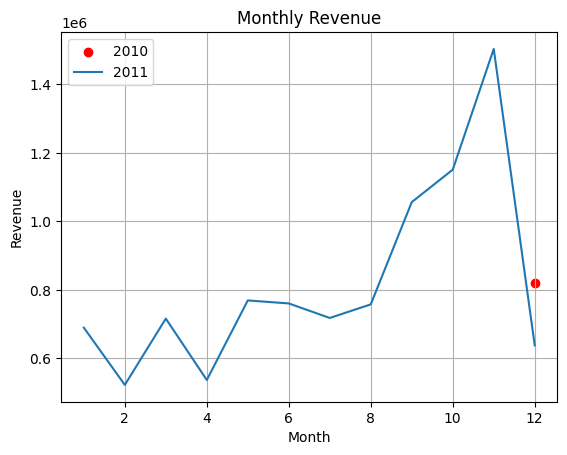

In [129]:
plt.scatter(total_price_2010.index, total_price_2010["TotalPrice"], label=2010, color="red")
plt.plot(total_price_2011.index, total_price_2011["TotalPrice"], label=2011)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid()
plt.show()

### Vendite per giorno della settimana

In [37]:
dayname_sorted = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Sunday"]
df_clean["DayName"] = pd.Categorical(df_clean["DayName"], categories=dayname_sorted, ordered=True)

In [38]:
dayname_total_price = df_clean.groupby("DayName")["TotalPrice"].sum()

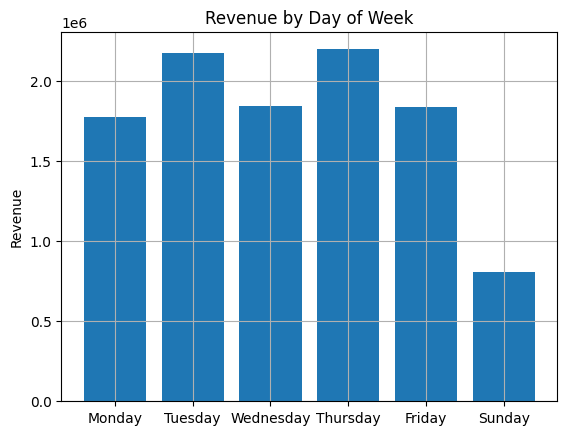

In [125]:
plt.bar(dayname_total_price.index, dayname_total_price)
plt.title("Revenue by Day of Week")
plt.ylabel("Revenue")
plt.grid()
plt.show()

### Geographic Analysis
L'analisi del fatturato per nazione indica che l'attività dell'azienda è concentrata nel proprio paese con un 85% di fatturato prodotto da clienti residenti in Inghilterra. Le sole Australia, Francia, Germania, Irlanda e Paesi Bassi arrivano insieme ad un 10%, mentre il resto delle nazioni si spartisce il restante 5%. Questa predominanza del mercato locale si riflette anche nell'analisi continentale, dove il 98% del fatturato viene prodotto in Europa: al secondo posto c'è l'Oceania con un misero 1%.

Anche in termini di numerosità, l'azienda presenta una forte concentrazione nel mercato domestico, con il 90% della clientela che risiede in Inghilterra e la quasi totalità di clientela residente nel continente europeo.

Il confronto tra quota di fatturato e quota di clienti suggerisce che i clienti esteri spendono mediamente di più di quelli inglesi o europei. Il calcolo della spesa media per nazione evidenzia differenze significative tra i paesi. L'Irlanda presenta il valore medio più elevato, seguita da Paesi Bassi, Singapore e Australia. Il Regno Unito si colloca invece in una posizione più bassa nella classifica. A livello continentale, è l'Oceania ha registrare un valore medio della spesa ben al di sopra di quella europea.

Tale evidenza potrebbe rappresentare un potenziale margine di sviluppo nei mercati esteri, da approfondire attraverso analisi di marginalità e sostenibilità operativa.


### Fatturato per nazione

In [40]:
country_revenue = df_clean.groupby("Country")["TotalPrice"].sum().sort_values()
country_revenue / total_revenue

Country
Saudi Arabia            0.000014
Bahrain                 0.000071
Czech Republic          0.000078
RSA                     0.000094
Brazil                  0.000107
European Community      0.000122
Lithuania               0.000156
Lebanon                 0.000159
United Arab Emirates    0.000179
Malta                   0.000256
USA                     0.000336
Canada                  0.000345
Iceland                 0.000405
Unspecified             0.000445
Greece                  0.000447
Poland                  0.000689
Israel                  0.000764
Austria                 0.000958
Cyprus                  0.001269
Hong Kong               0.001455
Italy                   0.001643
Denmark                 0.001781
Channel Islands         0.001921
Singapore               0.002000
Finland                 0.002119
Portugal                0.003165
Norway                  0.003398
Japan                   0.003516
Sweden                  0.003605
Belgium                 0.003871
Sw

In [41]:
continent_revenue = df_clean.groupby("Continent")["TotalPrice"].sum().sort_values()

In [84]:
continent_revenue_share = continent_revenue / total_revenue
continent_revenue_share

Continent
Africa     0.000094
Other      0.000445
America    0.000788
Asia       0.008157
Oceania    0.013010
Europe     0.977505
Name: TotalPrice, dtype: float64

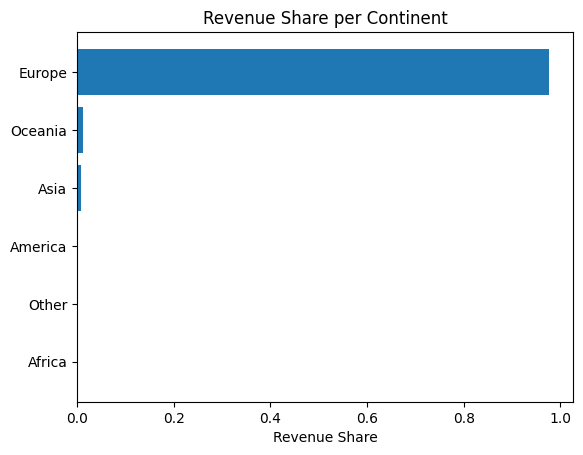

In [132]:
plt.barh(continent_revenue_share.index, continent_revenue_share)
plt.title("Revenue Share per Continent")
plt.xlabel("Revenue Share")
plt.show()

### Clienti per nazione

In [85]:
country_customers = df_clean.groupby("Country")["CustomerID"].nunique().sort_values()
country_customers / total_customers

Country
Hong Kong               0.000000
Brazil                  0.000230
European Community      0.000230
Czech Republic          0.000230
Lebanon                 0.000230
Lithuania               0.000230
Iceland                 0.000230
Singapore               0.000230
RSA                     0.000230
Saudi Arabia            0.000230
Malta                   0.000461
Bahrain                 0.000461
United Arab Emirates    0.000461
EIRE                    0.000691
Israel                  0.000691
Canada                  0.000922
USA                     0.000922
Unspecified             0.000922
Greece                  0.000922
Poland                  0.001383
Sweden                  0.001844
Cyprus                  0.001844
Japan                   0.001844
Netherlands             0.002074
Australia               0.002074
Channel Islands         0.002074
Denmark                 0.002074
Norway                  0.002305
Austria                 0.002535
Finland                 0.002766
It

In [89]:
continent_customers = df_clean.groupby("Continent")["CustomerID"].nunique().sort_values()

In [92]:
continent_customers_share = continent_customers / total_customers
continent_customers_share

Continent
Africa     0.000230
Other      0.000922
Oceania    0.002074
America    0.002074
Asia       0.004148
Europe     0.991012
Name: CustomerID, dtype: float64

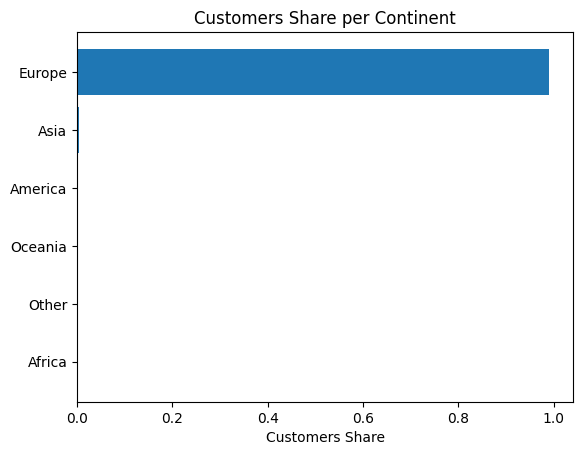

In [139]:
plt.barh(continent_customers_share.index, continent_customers_share)
plt.title("Customers Share per Continent")
plt.xlabel("Customers Share")
plt.show()

### Average Revenue per Country

In [107]:
customers_revenue = df_clean.groupby("CustomerID").agg(
    TotalPrice=("TotalPrice", "sum"),
    Country=("Country", "first"),
    Continent=("Continent", "first")
)

In [120]:
average_revenue_per_country = customers_revenue.groupby("Country")["TotalPrice"].mean().sort_values()
average_revenue_per_country 

Country
Saudi Arabia              145.920000
Bahrain                   274.200000
Unspecified               665.192500
Czech Republic            826.740000
USA                       895.097500
Canada                    916.595000
United Arab Emirates      951.140000
RSA                      1002.310000
Austria                  1053.722222
Brazil                   1143.600000
Greece                   1190.130000
Poland                   1222.441667
Italy                    1248.802857
European Community       1300.250000
Malta                    1362.795000
Lithuania                1661.060000
Lebanon                  1693.880000
Belgium                  1731.302500
Portugal                 1756.623158
United Kingdom           1857.950687
Finland                  1878.840000
Cyprus                   2022.187143
Spain                    2155.510714
Channel Islands          2271.171111
Denmark                  2312.740000
France                   2401.543793
Israel                   2405.

In [116]:
average_revenue_per_continent = customers_revenue.groupby("Continent")["TotalPrice"].mean().sort_values()
average_revenue_per_continent

Continent
Other        665.192500
America      932.263333
Africa      1002.310000
Europe      2016.079459
Asia        3900.110000
Oceania    15538.216667
Name: TotalPrice, dtype: float64

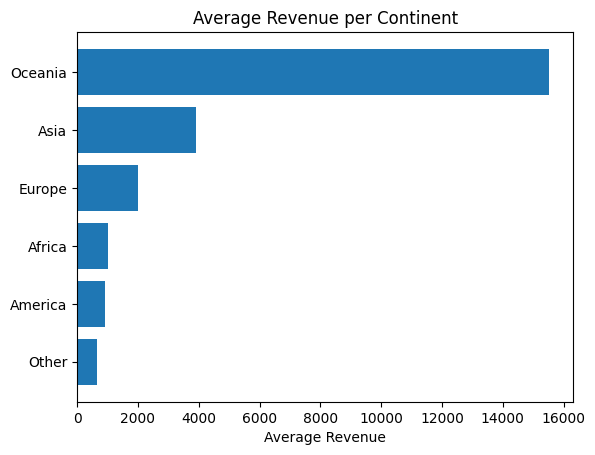

In [117]:
plt.barh(average_revenue_per_continent.index, average_revenue_per_continent)
plt.title("Average Revenue per Continent")
plt.xlabel("Average Revenue")
plt.show()

## Product Analysis
Dall'analisi condotta su quantità e fatturato, emerge che i prodotti più venduti in assoluto sono:

- RABBIT NIGHT LIGHT
- WHITE HANGING HEART T-LIGHT HOLDER
- JUMBO BAG RED RETROSPOT
- MEDIUM CERAMIC TOP STORAGE JAR
- PAPER CRAFT , LITTLE BIRDIE

In particolare, il prodotto PAPER CRAFT, LITTLE BIRDIE è nella top 3 sia per quantità venduta che per fatturato prodotto.

Dall'analisi della top 10 dei prodotti più venduti viene fuori che questi incidono per un 9% circa sulla quantità totale e per un 11% circa sul fatturato globale.

In [45]:
products = df_clean.groupby("StockCode").agg(
    Description=("Description", "first"),
    Quantity=("Quantity", "sum"),
    TotalPrice=("TotalPrice", "sum")
)

In [46]:
top10_quantity = products.sort_values("Quantity", ascending=False)\
    .head(10).sort_values("Quantity")
top10_revenue = products.sort_values("TotalPrice", ascending=False)\
    .head(10).sort_values("TotalPrice")

### Top 10 prodotti più venduti per quantità

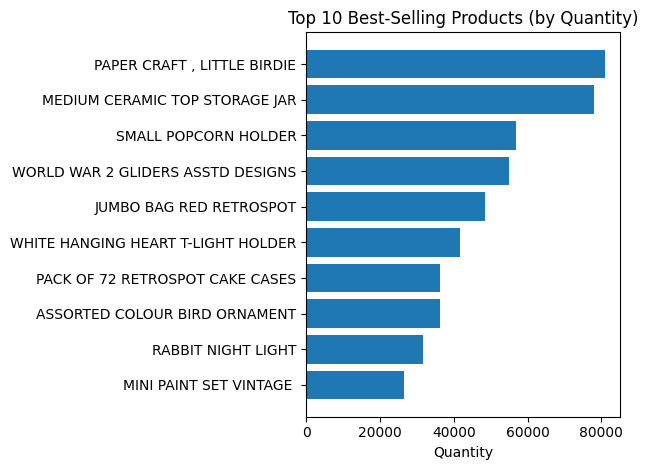

In [133]:
plt.barh(range(len(top10_quantity)), top10_quantity["Quantity"])
plt.yticks(range(len(top10_quantity)), top10_quantity["Description"])
plt.title("Top 10 Best-Selling Products (by Quantity)")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()

In [48]:
top10_quantity_share = (top10_quantity["Quantity"].sum() / products["Quantity"].sum()) * 100
top10_quantity_share

np.float64(8.714960468675294)

### Top 10 prodotti più venduti per fatturato

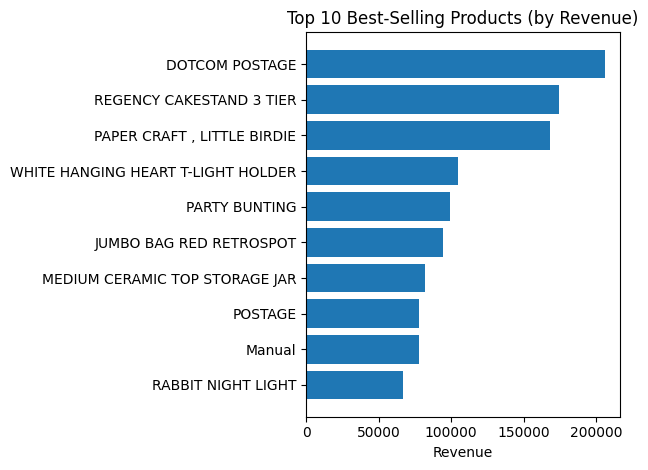

In [135]:
plt.barh(range(len(top10_revenue)), top10_revenue["TotalPrice"])
plt.yticks(range(len(top10_revenue)), top10_revenue["Description"])
plt.title("Top 10 Best-Selling Products (by Revenue)")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

In [50]:
top10_revenue_share = (top10_revenue["TotalPrice"].sum() / products["TotalPrice"].sum()) * 100
top10_revenue_share

np.float64(10.818960835920272)

## Customer Analysis
Dall’analisi emerge che il 17% del fatturato totale è generato dai 10 clienti con maggiore spesa, che rappresentano appena lo 0,2% del totale della clientela. Questo dato evidenzia una forte concentrazione del fatturato su un numero estremamente ristretto di clienti, suggerendo una significativa dipendenza dai top spender.

L’analisi della distribuzione della spesa per cliente mostra che la maggior parte dei clienti genera un fatturato contenuto, mentre una piccola quota presenta livelli di spesa molto elevati. Il confronto tra media e mediana (con la media significativamente superiore) conferma la presenza di una distribuzione asimmetrica positiva (right-skewed), tipica di contesti in cui pochi clienti ad alto valore influenzano fortemente il fatturato complessivo.

Il calcolo dell’Average Order Value (AOV) evidenzia come i top 10 clienti presentino un valore medio per ordine superiore alla media globale. Un’eccezione è rappresentata dal cliente 14911, il cui elevato fatturato deriva principalmente da un numero molto alto di ordini piuttosto che da un valore medio per ordine particolarmente elevato.

La Pareto Analysis mostra che circa l’80% del fatturato complessivo è generato dal 25–30% dei clienti. Questo risultato conferma la presenza di una concentrazione significativa del fatturato su una porzione limitata della clientela, sebbene non perfettamente aderente alla classica regola 80/20.

Infine, è stata costruita una tabella RFM per analizzare il comportamento dei clienti in base a: 
- Recency: giorni trascorsi dall’ultimo acquisto
- Frequency: numero di ordini effettuati
- Monetary: totale della spesa

Ad ogni metrica è stato assegnato uno score da 1 a 5, permettendo la costruzione di uno RFM score complessivo e la successiva segmentazione della clientela.

L’analisi evidenzia una presenza significativa di clienti classificati come _Lost_ e _Hibernating_, ovvero clienti inattivi o a basso valore, mentre il segmento _Champion_ rappresenta la fascia di clienti più fedeli e ad alto valore, contribuendo in maniera rilevante al fatturato.

In [51]:
df_customers = df_clean[df_clean["CustomerID"].notna()]
customers = df_customers.groupby("CustomerID").agg(
    TotalSpent=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique")
)

### Top 10 Spender

In [52]:
top10_spent_customers = customers["TotalSpent"].sort_values(ascending=False).head(10)\
    .sort_values(ascending=True)
top10_spent_customers

CustomerID
12346.0     77183.60
16029.0     80850.84
17511.0     91062.38
14156.0    117210.08
12415.0    124914.53
14911.0    143711.17
16446.0    168472.50
17450.0    194390.79
18102.0    259657.30
14646.0    280206.02
Name: TotalSpent, dtype: float64

In [53]:
top10_customer_revenue_share = (top10_spent_customers.sum() / customers["TotalSpent"].sum()) * 100
top10_customer_revenue_share

np.float64(17.301936168487227)

In [54]:
top10_customers_share = (10 / customers.shape[0]) * 100
top10_customers_share

0.23046784973496198

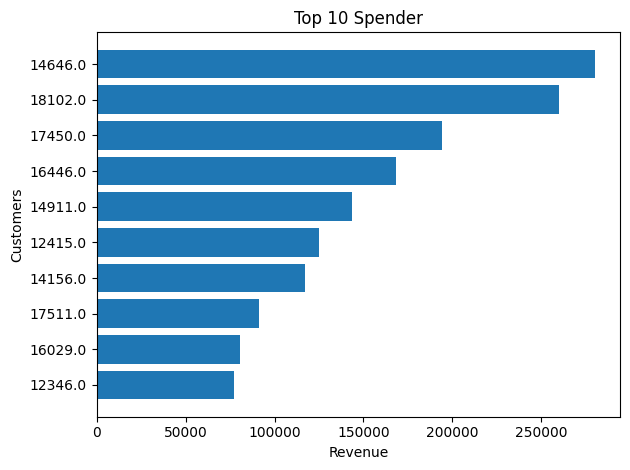

In [136]:
plt.barh(top10_spent_customers.index.astype(str), top10_spent_customers)
plt.title("Top 10 Spender")
plt.xlabel("Revenue")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

### Distribuzione della spesa clienti

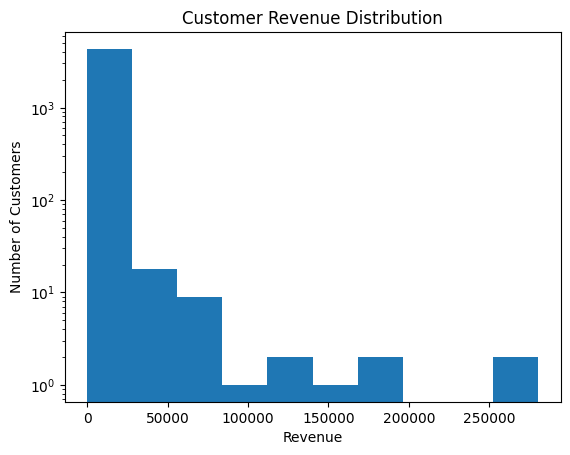

In [137]:
plt.hist(customers["TotalSpent"], log=True)
plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.show()

In [57]:
totalspent_mean = customers["TotalSpent"].mean()
totalspent_mean

np.float64(2048.21592394561)

In [58]:
totalspent_median = customers["TotalSpent"].median()
totalspent_median

np.float64(668.5600000000001)

### Average Order Value

In [59]:
customers["AOV"] = customers["TotalSpent"] / customers["Orders"]
customers

,TotalSpent,TotalQuantity,Orders,AOV
CustomerID,,,,
12346.0,77183.60,74215,1,77183.600000
12347.0,4310.00,2458,7,615.714286
12348.0,1797.24,2341,4,449.310000
12349.0,1757.55,631,1,1757.550000
12350.0,334.40,197,1,334.400000
...,...,...,...,...
18280.0,180.60,45,1,180.600000
18281.0,80.82,54,1,80.820000
18282.0,178.05,103,2,89.025000


In [60]:
customers["AOV"].mean()

np.float64(417.5275009295931)

In [61]:
customers.sort_values(by="TotalSpent", ascending=False).head(10)

,TotalSpent,TotalQuantity,Orders,AOV
CustomerID,,,,
14646.0,280206.02,197491,74,3786.567838
18102.0,259657.30,64124,60,4327.621667
17450.0,194390.79,69973,46,4225.886739
16446.0,168472.50,80997,2,84236.250000
14911.0,143711.17,80490,201,714.980945
12415.0,124914.53,77670,21,5948.310952
14156.0,117210.08,57768,55,2131.092364
17511.0,91062.38,64549,31,2937.496129
16029.0,80850.84,40108,63,1283.346667


### Pareto Analysis

In [62]:
customers_sorted = customers.sort_values("TotalSpent", ascending=False)

In [63]:
customers_sorted["CumulativeRevenue"] = (
    customers_sorted["TotalSpent"].cumsum() / customers_sorted["TotalSpent"].sum()
)

In [64]:
customers_sorted["CumulativeRevenuePerc"] = customers_sorted["CumulativeRevenue"] * 100
customers_sorted

,TotalSpent,TotalQuantity,Orders,AOV,CumulativeRevenue,CumulativeRevenuePerc
CustomerID,,,,,,
14646.0,280206.02,197491,74,3786.567838,0.031529,3.152914
18102.0,259657.30,64124,60,4327.621667,0.060746,6.074610
17450.0,194390.79,69973,46,4225.886739,0.082619,8.261920
16446.0,168472.50,80997,2,84236.250000,0.101576,10.157594
14911.0,143711.17,80490,201,714.980945,0.117747,11.774650
...,...,...,...,...,...,...
17956.0,12.75,1,1,12.750000,0.999998,99.999810
16454.0,6.90,3,2,3.450000,0.999999,99.999888
14792.0,6.20,2,1,6.200000,1.000000,99.999958


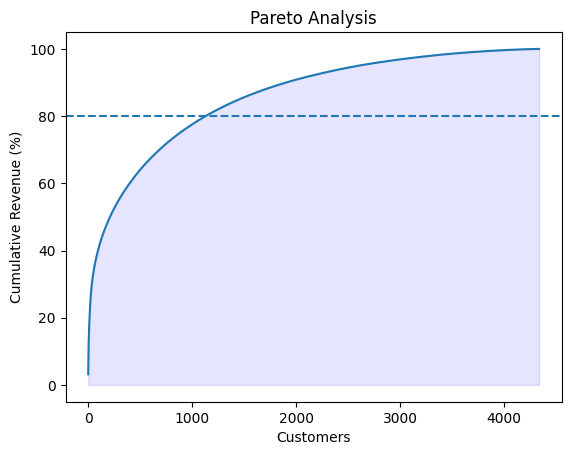

In [140]:
plt.plot(np.arange(len(customers_sorted)), customers_sorted["CumulativeRevenuePerc"])
plt.fill_between(np.arange(len(customers_sorted)), customers_sorted["CumulativeRevenuePerc"], 
                 color="blue", alpha=0.1)
plt.axhline(80, linestyle="--")
plt.title("Pareto Analysis")
plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue (%)")
plt.show()

### RFM Analysis

In [66]:
last_date = df_clean["InvoiceDate"].max()

In [67]:
customers["LastOrderDate"] = df_customers.groupby("CustomerID")["InvoiceDate"].max()

In [68]:
rfm_analysis = customers[["TotalSpent", "Orders"]].copy()

rfm_analysis.rename(columns={
    "TotalSpent": "Monetary",
    "Orders": "Frequency"
}, inplace=True)

In [69]:
rfm_analysis["Recency"] = (
    last_date - customers["LastOrderDate"]
).dt.days

In [70]:
rfm_analysis = rfm_analysis[["Recency", "Frequency", "Monetary"]]

In [71]:
rfm_analysis["Frequency"].value_counts()

Frequency
1      1494
2       835
3       508
4       387
5       243
6       172
7       143
8        98
9        68
10       54
11       52
12       45
13       30
15       28
14       20
17       18
18       14
20       12
19       12
21       11
16       11
25        8
26        7
28        6
22        5
23        5
30        4
32        3
31        3
37        3
24        3
27        3
34        3
38        2
33        2
55        2
47        2
39        2
210       1
86        1
97        1
35        1
62        1
50        1
57        1
44        1
93        1
74        1
201       1
48        1
41        1
91        1
63        1
51        1
29        1
46        1
124       1
45        1
60        1
Name: count, dtype: int64

In [72]:
rfm_analysis["R_score"] = pd.qcut(rfm_analysis["Recency"], 5, labels=[5,4,3,2,1], duplicates="drop")

bins = [0, 1, 3, 6, 10, rfm_analysis["Frequency"].max()+1]
rfm_analysis["F_score"] = pd.cut(rfm_analysis["Frequency"], bins=bins, labels=[1,2,3,4,5], right=True)

rfm_analysis["M_score"] = pd.qcut(rfm_analysis["Monetary"], 5, labels=[1,2,3,4,5])

In [73]:
rfm_analysis["RFM_score"] = rfm_analysis["R_score"].astype(str) + \
                            rfm_analysis["F_score"].astype(str) + \
                            rfm_analysis["M_score"].astype(str)

### Customer Segmentation

In [74]:
customers_segment_map = {
    "Champion":["555", "554", "544", "545", "454", "455", "445"],
    "Loyal customer": ["543", "444", "435", "355", "354", "345", "344", "335"],
    "Potential loyalist": ["553", "551", "552", "541", "542", "533", "532", "531", "452", "451", "442", "441", "431", "453", "433", "432", "423", "353", "352", "351", "342", "341", "333", "323"],
    "New customer": ["512", "511", "422", "421", "412", "411", "311"],
    "Promising": ["525", "524", "523", "522", "521", "515", "514", "513", "425", "424", "413", "414", "415", "315", "314", "313"],
    "Need attention": ["535", "534", "443", "434", "343", "334", "325", "324"],
    "Cannot lose him": ["155", "154", "144", "214", "215", "115", "114", "113"],
    "About to sleep": ["331", "321", "312", "221", "213"],
    "At risk": ["255", "254", "245", "244", "253", "252", "243", "242", "235", "234", "225", "224", "153", "152", "145", "143", "142", "135", "134", "133", "125", "124"],
    "Hibernating": ["332", "322", "231", "241", "251", "233", "232", "223", "222", "132", "123", "122", "212", "211"],
    "Lost": ["111", "112", "121", "131", "141", "151"]
}

In [75]:
def map_rfm_segment(score):
    for segment, score_list in customers_segment_map.items():
        if score in score_list:
            return segment

In [76]:
rfm_analysis["Segment"] = rfm_analysis["RFM_score"].astype(str).apply(map_rfm_segment)

In [77]:
segment_customers = rfm_analysis["Segment"].value_counts().sort_values()
segment_customers

Segment
Cannot lose him       113
About to sleep        226
Loyal customer        233
At risk               301
Potential loyalist    374
Promising             386
New customer          437
Need attention        456
Champion              540
Lost                  566
Hibernating           707
Name: count, dtype: int64

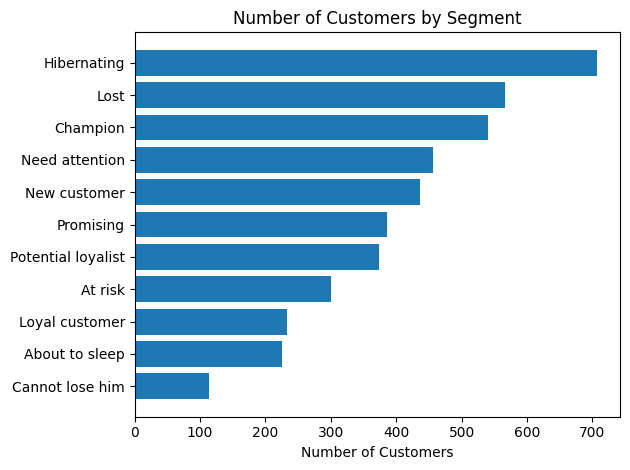

In [142]:
plt.barh(segment_customers.index, segment_customers)
plt.title("Number of Customers by Segment")
plt.xlabel("Number of Customers")
plt.tight_layout()
plt.show()

In [79]:
segment_revenue = rfm_analysis.groupby("Segment")["Monetary"].sum().sort_values()
segment_revenue

Segment
About to sleep          88217.100
New customer           100729.350
Lost                   124670.490
Cannot lose him        209473.170
Potential loyalist     258342.781
Hibernating            294677.292
Promising              580195.100
At risk                668616.241
Need attention         787987.200
Loyal customer         872120.720
Champion              4902179.450
Name: Monetary, dtype: float64

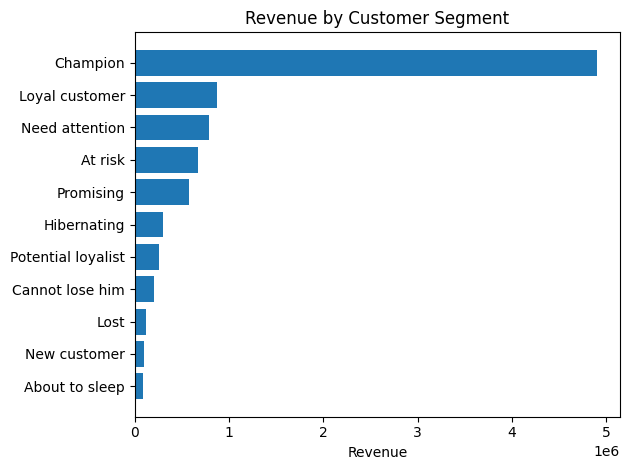

In [144]:
plt.barh(segment_revenue.index, segment_revenue)
plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()